In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("bank.csv")
print(df.shape)
df.head()

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
None
age          0
job          0
marital      0
education    0
default      0
balance      0
hous

=== Target Variable (deposit) ===
deposit
no     5873
yes    5289
Name: count, dtype: int64

Percentage:
deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_13332\3222228718.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='deposit', data=df, palette='Set2')


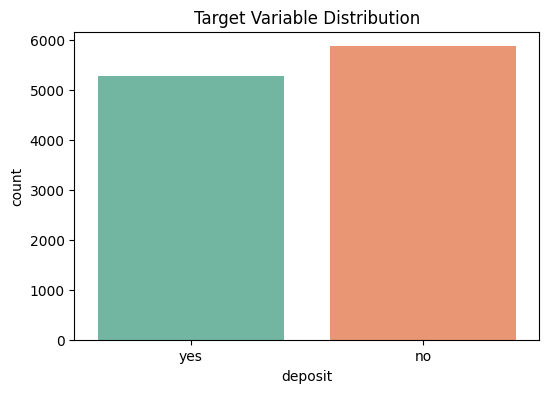

In [4]:
##Target variable distribution
print("=== Target Variable (deposit) ===")
print(df['deposit'].value_counts())
print("\nPercentage:")
print(df['deposit'].value_counts(normalize=True) * 100)

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='deposit', data=df, palette='Set2')
plt.title("Target Variable Distribution")
plt.show()

Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


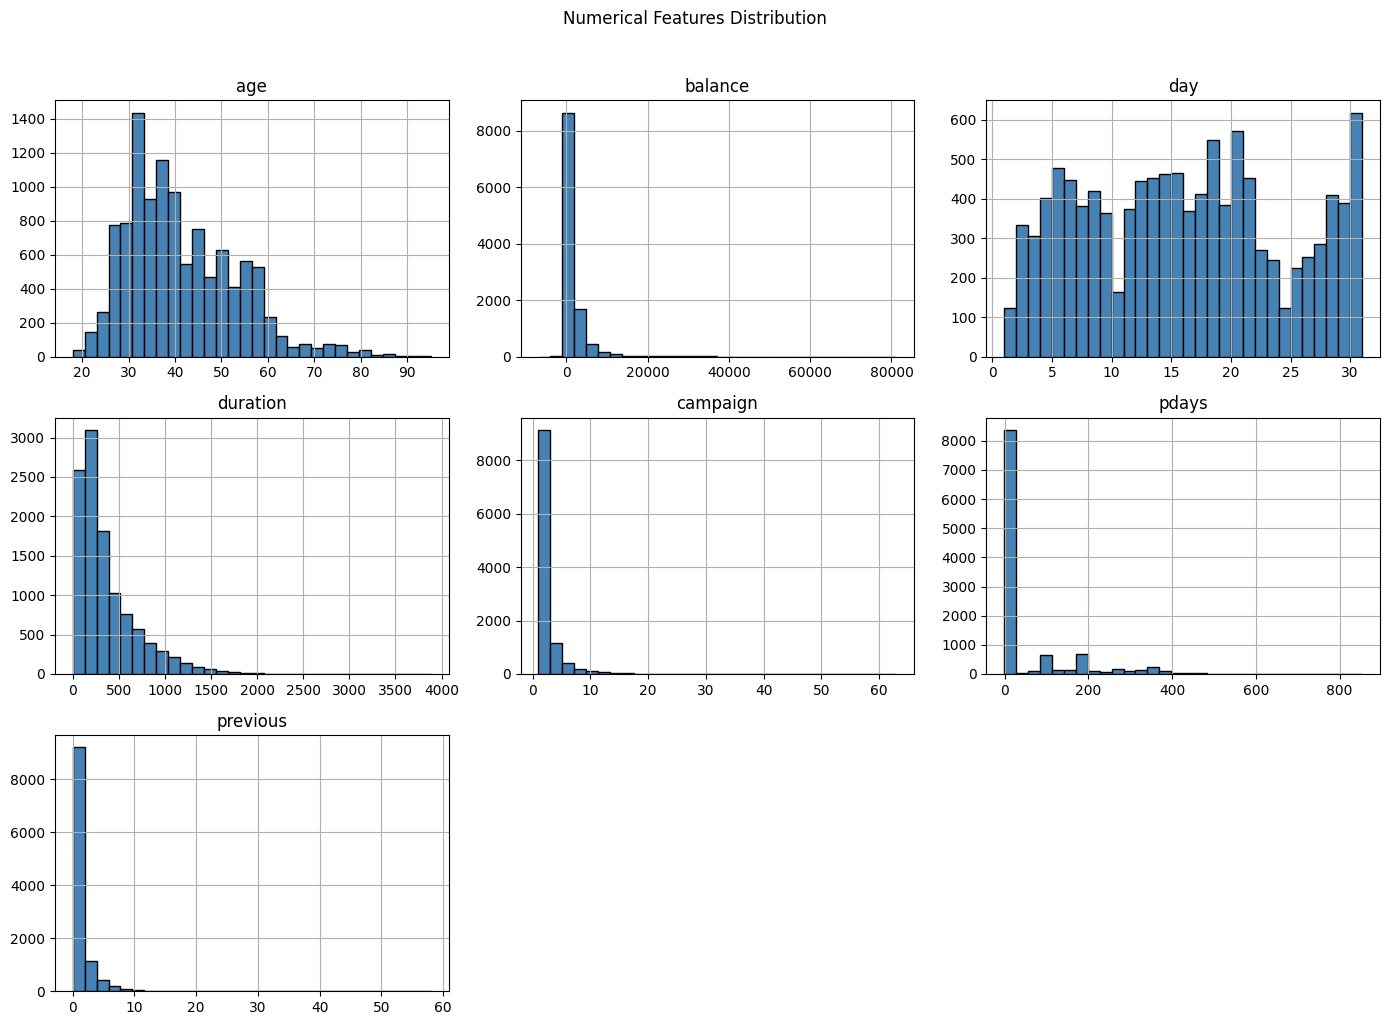

In [5]:
#Numerical feature
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns:", num_cols)

df[num_cols].hist(figsize=(14, 10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle("Numerical Features Distribution", y=1.02)
plt.tight_layout()
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_13332\3913506632.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='deposit', y='age', data=df, ax=axes[0], palette='Set2')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_13332\3913506632.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='deposit', y='balance', data=df, ax=axes[1], palette='Set2')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_13332\3913506632.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='deposit', y='duration', data=df, ax=axes[2], palette='Set2')


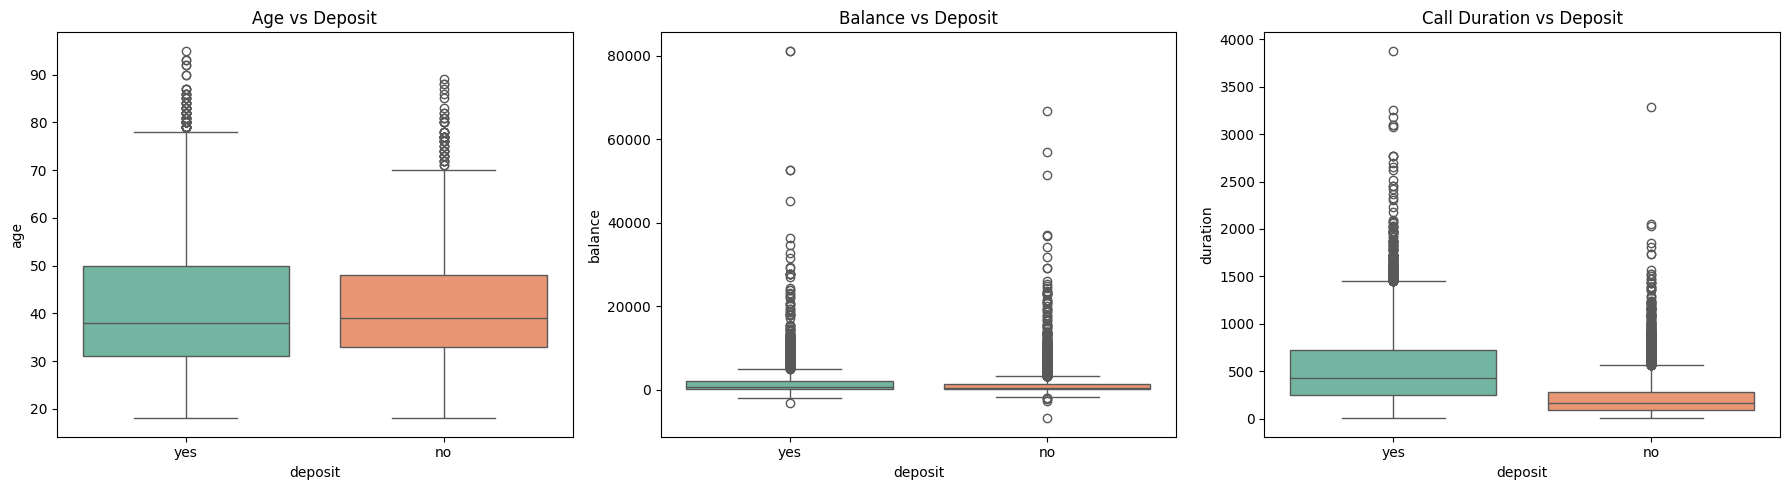

In [6]:
#Target vs key feature
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='deposit', y='age', data=df, ax=axes[0], palette='Set2')
axes[0].set_title("Age vs Deposit")

sns.boxplot(x='deposit', y='balance', data=df, ax=axes[1], palette='Set2')
axes[1].set_title("Balance vs Deposit")

sns.boxplot(x='deposit', y='duration', data=df, ax=axes[2], palette='Set2')
axes[2].set_title("Call Duration vs Deposit")

plt.tight_layout()
plt.show()


In [7]:

# Let's see all categorical columns and their unique values
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

job: ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']
marital: ['married' 'single' 'divorced']
education: ['secondary' 'tertiary' 'primary' 'unknown']
default: ['no' 'yes']
housing: ['yes' 'no']
loan: ['no' 'yes']
contact: ['unknown' 'cellular' 'telephone']
month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
poutcome: ['unknown' 'other' 'failure' 'success']
deposit: ['yes' 'no']


In [8]:
from sklearn.preprocessing import LabelEncoder

# These columns only have 2 values (yes/no)
binary_cols = ['default', 'housing', 'loan', 'deposit']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"{col}: encoded → {df[col].unique()}")

default: encoded → [0 1]
housing: encoded → [1 0]
loan: encoded → [0 1]
deposit: encoded → [1 0]


In [9]:
# These columns have multiple categories
multi_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (11162, 43)


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,0,2343,1,0,5,1042,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
1,56,0,45,0,0,5,1467,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
2,41,0,1270,1,0,5,1389,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
3,55,0,2476,1,0,5,579,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
4,54,0,184,0,0,5,673,2,-1,0,...,False,False,False,True,False,False,False,False,False,True


In [10]:
print("=== Final Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes.value_counts())

print("\n=== Any remaining non-numeric columns? ===")
print(df.select_dtypes(include='object').columns.tolist())

df.head()

=== Final Shape ===
(11162, 43)

=== Data Types ===
bool     32
int64    11
Name: count, dtype: int64

=== Any remaining non-numeric columns? ===
[]


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,0,2343,1,0,5,1042,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
1,56,0,45,0,0,5,1467,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
2,41,0,1270,1,0,5,1389,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
3,55,0,2476,1,0,5,579,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
4,54,0,184,0,0,5,673,2,-1,0,...,False,False,False,True,False,False,False,False,False,True


In [11]:
#split features and target
X = df.drop('deposit', axis=1)  # All columns except target
y = df['deposit']                # Only the target column

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (11162, 42)
Target shape: (11162,)
Target distribution:
 deposit
0    5873
1    5289
Name: count, dtype: int64


In [12]:
#train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% data for testing
    random_state=42,    # fixes randomness so results are reproducible
    stratify=y          # keeps same yes/no ratio in both splits
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("\nTraining target distribution:\n", y_train.value_counts())
print("\nTesting target distribution:\n", y_test.value_counts())

Training size: (8929, 42)
Testing size: (2233, 42)

Training target distribution:
 deposit
0    4698
1    4231
Name: count, dtype: int64

Testing target distribution:
 deposit
0    1175
1    1058
Name: count, dtype: int64


In [13]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)      # only transform, NOT fit!

print("Scaling done!")
print("Mean of first feature (should be ~0):", X_train[:, 0].mean().round(3))
print("Std of first feature (should be ~1):", X_train[:, 0].std().round(3))

Scaling done!
Mean of first feature (should be ~0): 0.0
Std of first feature (should be ~1): 1.0


In [14]:
#train logistic regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

print("Logistic Regression trained!")
print("Training Accuracy:", lr_model.score(X_train, y_train))
print("Testing Accuracy:", lr_model.score(X_test, y_test))

Logistic Regression trained!
Training Accuracy: 0.8264083324000447
Testing Accuracy: 0.825794894760412


In [15]:
#Train random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    random_state=42,
    n_jobs=-1           # use all CPU cores
)
rf_model.fit(X_train, y_train)

print("Random Forest trained!")
print("Training Accuracy:", rf_model.score(X_train, y_train))
print("Testing Accuracy:", rf_model.score(X_test, y_test))

Random Forest trained!
Training Accuracy: 1.0
Testing Accuracy: 0.8575906851768921


                 Model  Train Accuracy  Test Accuracy  Difference
0  Logistic Regression           0.826          0.826       0.001
1        Random Forest           1.000          0.858       0.142


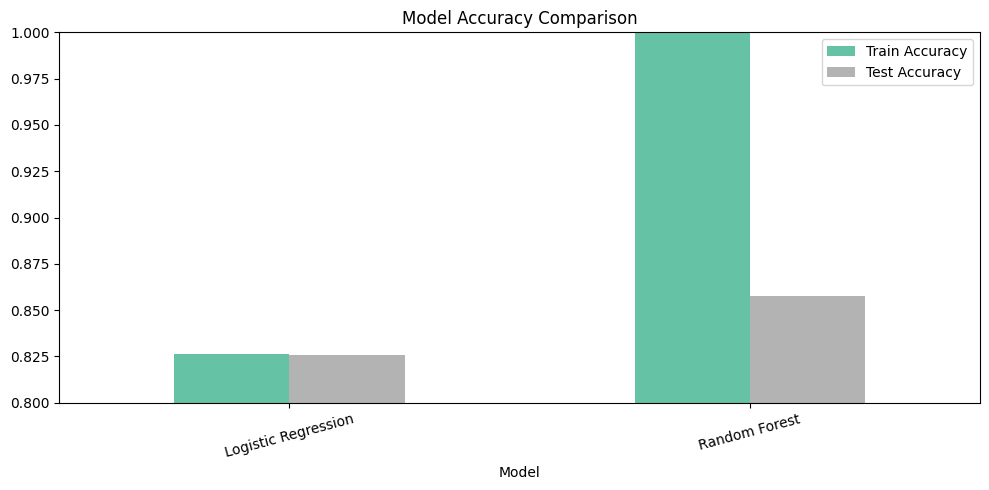

In [16]:
results = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Train Accuracy': [
        lr_model.score(X_train, y_train),
        rf_model.score(X_train, y_train)
    ],
    'Test Accuracy': [
        lr_model.score(X_test, y_test),
        rf_model.score(X_test, y_test)
    ]
}

results_df = pd.DataFrame(results)
results_df['Difference'] = (results_df['Train Accuracy'] - results_df['Test Accuracy']).round(3)
print(results_df.round(3))

# Plot
results_df.plot(x='Model', y=['Train Accuracy', 'Test Accuracy'], 
                kind='bar', figsize=(10, 5), colormap='Set2')
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

In [17]:
# Get predictions from all 2 models
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)


# Get probability scores (needed for ROC curve)
lr_prob = lr_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]


print("Predictions ready!")
print("Sample LR predictions:", lr_pred[:10])
print("Sample LR probabilities:", lr_prob[:10].round(3))

Predictions ready!
Sample LR predictions: [1 1 1 0 1 0 0 0 1 1]
Sample LR probabilities: [0.55  0.678 0.667 0.06  0.767 0.012 0.116 0.379 0.995 0.888]


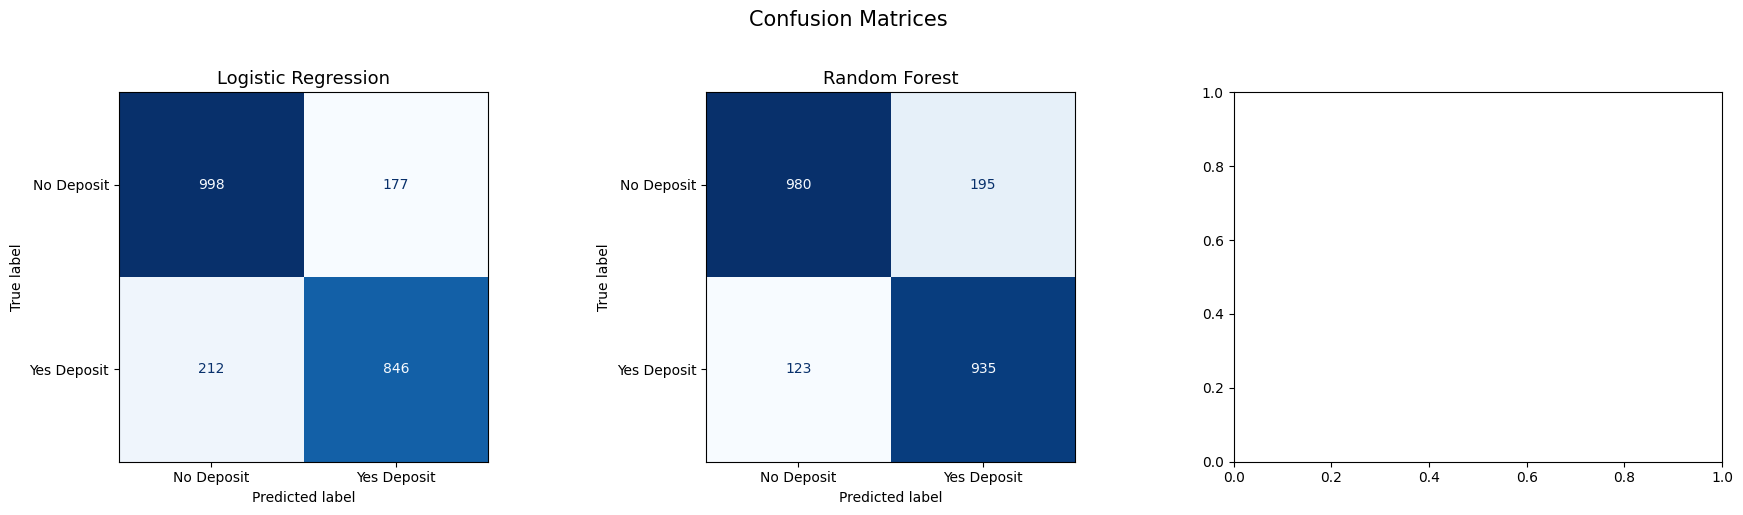

In [18]:
#confusion matrix for all models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred
}

for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['No Deposit', 'Yes Deposit'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=13)

plt.suptitle("Confusion Matrices", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
#classification report
from sklearn.metrics import classification_report

for name, pred in models.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    print(classification_report(y_test, pred, 
                                target_names=['No Deposit', 'Yes Deposit']))


  Logistic Regression
              precision    recall  f1-score   support

  No Deposit       0.82      0.85      0.84      1175
 Yes Deposit       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.83      0.83      0.83      2233


  Random Forest
              precision    recall  f1-score   support

  No Deposit       0.89      0.83      0.86      1175
 Yes Deposit       0.83      0.88      0.85      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



In [20]:
!pip install shap


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import shap

# Random Forest uses different explainer than XGBoost
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values - Random Forest returns a list (one per class)
shap_values = explainer.shap_values(X_test)

feature_names = X.columns.tolist()

# For binary classification, shap_values[1] = values for class 1 (Subscribed)
shap_vals_class1 = shap_values[1]

print("Done!")
print("SHAP values shape:", shap_vals_class1.shape)

In [ ]:
#explain 5 individual customers
X_test_df = pd.DataFrame(X_test, columns=feature_names)

for i in range(5):
    actual = 'Subscribed ✅' if y_test.iloc[i] == 1 else 'Not Subscribed ❌'
    predicted_val = rf_model.predict(X_test[i:i+1])[0]
    predicted = 'Subscribed ✅' if predicted_val == 1 else 'Not Subscribed ❌'
    confidence = rf_model.predict_proba(X_test[i:i+1])[0][1]

    print(f"\n{'='*45}")
    print(f" Customer #{i+1}")
    print(f" Actual:     {actual}")
    print(f" Predicted:  {predicted}")
    print(f" Confidence: {confidence:.2%}")
    print(f"{'='*45}")

    top_idx = np.argsort(np.abs(shap_vals_class1[i]))[::-1][:5]

    print(" Top 5 Reasons:")
    for idx in top_idx:
        direction = "pushed TOWARD yes 🔴" if shap_vals_class1[i][idx] > 0 else "pushed TOWARD no 🔵"
        print(f"   • {feature_names[idx]}: {direction} (impact: {shap_vals_class1[i][idx]:.3f})")


 Customer #1
 Actual:     Not Subscribed ❌
 Predicted:  Subscribed ✅
 Confidence: 75.00%
 Top 5 Reasons:
   • age: pushed TOWARD yes 🔴 (impact: 0.022)
   • default: pushed TOWARD no 🔵 (impact: -0.022)

 Customer #2
 Actual:     Subscribed ✅
 Predicted:  Subscribed ✅
 Confidence: 70.00%
 Top 5 Reasons:
   • default: pushed TOWARD yes 🔴 (impact: 0.000)
   • age: pushed TOWARD no 🔵 (impact: -0.000)

 Customer #3
 Actual:     Not Subscribed ❌
 Predicted:  Not Subscribed ❌
 Confidence: 50.00%
 Top 5 Reasons:
   • default: pushed TOWARD no 🔵 (impact: -0.014)
   • age: pushed TOWARD yes 🔴 (impact: 0.014)

 Customer #4
 Actual:     Not Subscribed ❌
 Predicted:  Not Subscribed ❌
 Confidence: 6.00%
 Top 5 Reasons:
   • age: pushed TOWARD no 🔵 (impact: -0.018)
   • default: pushed TOWARD yes 🔴 (impact: 0.018)

 Customer #5
 Actual:     Subscribed ✅
 Predicted:  Subscribed ✅
 Confidence: 69.00%
 Top 5 Reasons:
   • age: pushed TOWARD no 🔵 (impact: -0.007)
   • default: pushed TOWARD yes 🔴 (impact